In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
os.chdir('/content/drive/MyDrive/Stock/交易策略')

Mounted at /content/drive


In [ ]:
! pip install backtrader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

# 使用 FinMind.ipynb 所抓取的基本面資料
df = pd.read_csv("2330_Cal.csv") # 2023-05-01	-> 2026-07-01
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,stock_id,Trading_Volume,Trading_money,open,max,min,close,spread,Trading_turnover,...,K,D,RSI_7,RSI_14,BB_Upper,BB_Middle,BB_Lower,MACD,MACD_Signal,MACD_Hist
0,2023-05-02,2330,17142380,8572554842,500.0,502.0,496.5,501.0,-1.0,18247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-05-03,2330,12694698,6305914905,496.0,498.0,495.0,496.0,-5.0,25658,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-05-04,2330,13699933,6818128036,497.0,499.5,496.0,498.0,2.0,14801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-05-05,2330,7898012,3949232374,500.0,502.0,498.5,500.0,2.0,10944,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-05-08,2330,11737287,5932968954,509.0,509.0,502.0,504.0,4.0,13709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 黃金交叉和死亡交叉的買入賣出

In [ ]:
import pandas as pd
import backtrader as bt

# 資料處理
df_bt = df.copy()
df_bt = df_bt[['date', 'open', 'max', 'min', 'close', 'K', 'D', 'Trading_Volume']]

df_bt = df_bt.rename(columns={
    "max": "high",
    "min": "low",
    "Trading_Volume": "volume"
})

df_bt = df_bt.dropna().reset_index(drop=True)
df_bt['date'] = pd.to_datetime(df_bt['date'])
df_bt = df_bt.set_index("date")

class PandasData(bt.feeds.PandasData):
    lines = ('k', 'd')
    params = (
        ('datetime', None),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
        ('k', 'K'),
        ('d', 'D'),
    )

# 手續費與證交稅
class TaiwanStockCommission(bt.CommissionInfo):
    params = (
        ("commission", 0.001425),
        ("tax", 0.003),
    )

    def _getcommission(self, size, price, pseudoexec):
        value = abs(size) * price
        commission = value * self.p.commission
        if size < 0:
            commission += value * self.p.tax
        return commission

# 使用ALLIn買法，由於明天的開盤價尚未發生，設計上是使用「當天收盤價」來計算明天要買的股數，但有可能隔天大幅開高，因此保留 5% 現金
class AllInSizer(bt.Sizer):
    params = (("reserve", 0.05),)

    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            cash *= (1 - self.p.reserve)
            price = data.close[0]
            cost_per_share = price * (1 + comminfo.p.commission)
            size = int(cash / cost_per_share)
            return max(size, 0)
        return self.broker.getposition(data).size

# KD 策略
class KDStrategy(bt.Strategy):
    params = dict(
        stop_loss=0.10, # 停損條件
    )

    def __init__(self):
        self.k = self.data.k
        self.d = self.data.d
        self.cross = bt.ind.CrossOver(self.k, self.d)
        self.order = None
        self.buyprice = None

        # 用於儲存明細紀錄的列表
        self.trades_history = []

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:
            date = self.data.datetime.date(0)
            exec_price = order.executed.price
            exec_size = abs(order.executed.size)
            exec_value = exec_price * exec_size

            # 手續費與證交稅計算
            comminfo = order.comminfo
            commission = exec_value * comminfo.p.commission
            tax = (exec_value * comminfo.p.tax) if order.issell() else 0.0

            # 取得成交當下的總資產 (用於計算累積報酬率)
            current_value = self.broker.getvalue()
            pnl_pct = (current_value / 1_000_000 - 1) * 100

            if order.isbuy():
                self.buyprice = exec_price
                action = "買入"
            else:
                action = "賣出"

            # 記錄至歷史列表中
            self.trades_history.append({
                "交易日期": date,
                "買賣別": action,
                "成交價": round(exec_price, 2),
                "成交量(股)": exec_size,
                "交易金額": round(exec_value, 2),
                "手續費": round(commission, 2),
                "證交稅": round(tax, 2),
                "總資產": round(current_value, 2),
                "目前報酬率(%)": round(pnl_pct, 2)
            })

            print(f"{date} {action} | 價格:{exec_price:.2f} | 成交量:{exec_size} | 手續費:{commission:.0f} | 證交稅:{tax:.0f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print(f"{self.data.datetime.date(0)} 交易失敗 : {order.getstatusname()}")

        self.order = None

    def next(self):
        if self.order:
            return

        if self.position:
            loss = (self.data.close[0] - self.buyprice) / self.buyprice

            if loss <= -self.p.stop_loss:
                print(f"{self.data.datetime.date(0)}停損觸發")
                self.order = self.close()
                return

            if self.cross < 0:
                print(f"{self.data.datetime.date(0)}KD死亡交叉")
                self.order = self.close()
                return
        else:
            if self.cross > 0:
                print(f"{self.data.datetime.date(0)}KD黃金交叉")
                self.order = self.buy()

    def stop(self):
      # 回測結束時，如果還有持股，強制以最後一天價格賣出
      if self.position:
        print(f"回測結束，強制結算持股：{self.position.size}股")
        self.close()

# 執行回測與表格輸出
cerebro = bt.Cerebro()
cerebro.addstrategy(KDStrategy)
cerebro.addsizer(AllInSizer, reserve=0.05)

data = PandasData(dataname=df_bt)
cerebro.adddata(data)
cerebro.broker.setcash(1_000_000)

comminfo = TaiwanStockCommission()
cerebro.broker.addcommissioninfo(comminfo)

# 夏普比率與最大回撤
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.015, annualize=True, timeframe=bt.TimeFrame.Days)
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

print(f"初始資金：{cerebro.broker.getvalue():,.0f}")
results = cerebro.run()

# 轉為 DataFrame
strat = results[0]
df_trades = pd.DataFrame(strat.trades_history)

final_val = cerebro.broker.getvalue()
pnl_pct = (final_val / 1_000_000 - 1) * 100

# 不下單賣出，而是直接拿最後一天的收盤價 data.close[0] 乘以持股數，當作最後的資產淨值。
if strat.position:
    last_date = strat.data.datetime.date(0)
    pos_size = strat.position.size
    close_price = strat.data.close[0]
    unrealized_value = pos_size * close_price

    # 建立最後一筆紀錄
    unrealized_row = pd.DataFrame([{
        "交易日期": last_date,
        "買賣別": "結算",
        "成交價": round(close_price, 2),
        "成交量(股)": pos_size,
        "交易金額": round(unrealized_value, 2),
        "手續費": 0.0,
        "證交稅": 0.0,
        "總資產": round(final_val, 2),
        "目前報酬率(%)": round(pnl_pct, 2)
    }])

    # 併入原本的交易紀錄表格中
    df_trades = pd.concat([df_trades, unrealized_row], ignore_index=True)

df_trades.to_csv('df_trades.csv', index=False)

# 計算與列印績效指標
print("\n" + "="*30)
print("       策略整體績效評估       ")
print("="*30)

# 最大回撤 (MDD)
'''
最大回撤（Maximum Drawdown, MDD）是指投資組合或交易帳戶在特定期間內，資產淨值從歷史「最高點」跌至「最低點」的最大跌幅。
意義：MDD 數值越小，代表資金曲線越平滑，抗風險能力越強；MDD 越大，代表波動越劇烈，且事後需要極大的漲幅才能回本（例如：帳戶若發生 50% 的最大回撤，則需要 100% 的獲利才能彌補損失）。
合理範圍：一般波段操作與保守配置的策略，最大回撤多落在 10% 至 30% 之間。若超過 30% - 40% 則屬於高風險，需謹慎評估。
'''
mdd = strat.analyzers.drawdown.get_analysis()['max']['drawdown']

# 夏普比率 (Sharpe Ratio)
'''
夏普值 < 0： 報酬率甚至不如放在銀行定存，承擔風險卻不划算。
夏普值 1.0 ~ 1.9： 表現良好，具備不錯的風險調整後報酬。
夏普值 ≥ 2.0： 表現優秀，在控管風險下創造了極佳的收益。
'''
sharpe_info = strat.analyzers.sharpe.get_analysis()
sharpe = sharpe_info.get('sharperatio', None)

# 勝率與賺賠比計算
raw_trades = df_trades[df_trades['買賣別'] != '結算'].copy()
trade_pnls = []

# 將買入與賣出進行配對計算
buy_record = None
for _, row in df_trades.iterrows():
    if row['買賣別'] == '買入':
        buy_record = row
    elif row['買賣別'] in ['賣出', '結算'] and buy_record is not None:
        # 計算包含交易成本後的每筆純利潤
        cost = buy_record['交易金額'] + buy_record['手續費']
        revenue = row['交易金額'] - row['手續費'] - row['證交稅']
        pnl = revenue - cost
        trade_pnls.append(pnl)
        buy_record = None

trade_pnls = np.array(trade_pnls)

if len(trade_pnls) > 0:
    wins = trade_pnls[trade_pnls > 0]
    losses = trade_pnls[trade_pnls < 0]

    win_rate = (len(wins) / len(trade_pnls)) * 100
    avg_win = np.mean(wins) if len(wins) > 0 else 0
    avg_loss = abs(np.mean(losses)) if len(losses) > 0 else 0
    profit_factor = (avg_win / avg_loss) if avg_loss != 0 else np.nan
else:
    win_rate = 0.0
    profit_factor = 0.0

# 總結果
print(f"最終資金：{final_val:,.2f} 元")
print(f"總報酬率：{pnl_pct:.2f} %")
print(f"最大回撤 (MDD)：{mdd:.2f} %")
print(f"夏普比率(Sharpe)：{sharpe:.2f}" if sharpe is not None else "夏普比率 (Sharpe)：無法計算 (波動不足或無交易)")
print(f"總交易次數：{len(trade_pnls)} 次")
print(f"勝率：{win_rate:.2f} %")
print(f"賺賠比：{profit_factor:.2f}")
print("="*30)
print("\n=== 交易紀錄表 ===")
display(df_trades)

初始資金：1,000,000
2023-05-26KD黃金交叉
2023-05-29 買入 | 價格:574.00 | 成交量:1676 | 手續費:1371 | 證交稅:0
2023-05-30KD死亡交叉
2023-05-31 賣出 | 價格:560.00 | 成交量:1676 | 手續費:1337 | 證交稅:2816
2023-06-06KD黃金交叉
2023-06-07 買入 | 價格:561.00 | 成交量:1644 | 手續費:1314 | 證交稅:0
2023-06-08KD死亡交叉
2023-06-09 賣出 | 價格:561.00 | 成交量:1644 | 手續費:1314 | 證交稅:2767
2023-06-09KD黃金交叉
2023-06-12 買入 | 價格:574.00 | 成交量:1621 | 手續費:1326 | 證交稅:0
2023-06-15KD死亡交叉
2023-06-16 賣出 | 價格:590.00 | 成交量:1621 | 手續費:1363 | 證交稅:2869
2023-06-30KD黃金交叉
2023-07-03 買入 | 價格:578.00 | 成交量:1623 | 手續費:1337 | 證交稅:0
2023-07-06KD死亡交叉
2023-07-07 賣出 | 價格:565.00 | 成交量:1623 | 手續費:1307 | 證交稅:2751
2023-07-11KD黃金交叉
2023-07-12 買入 | 價格:574.00 | 成交量:1577 | 手續費:1290 | 證交稅:0
2023-07-19KD死亡交叉
2023-07-20 賣出 | 價格:580.00 | 成交量:1577 | 手續費:1303 | 證交稅:2744
2023-07-26KD黃金交叉
2023-07-27 買入 | 價格:570.00 | 成交量:1615 | 手續費:1312 | 證交稅:0
2023-07-31KD死亡交叉
2023-08-01 賣出 | 價格:565.00 | 成交量:1615 | 手續費:1300 | 證交稅:2737
2023-08-01KD黃金交叉
2023-08-02 買入 | 價格:567.00 | 成交量:1589 | 手續費:1284 | 證交稅:0
2023-08-02KD死亡交叉
2

,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2023-05-29,買入,574.0,1676,962024.0,1370.88,0.00,988573.12,-1.14
1,2023-05-31,賣出,560.0,1676,938560.0,1337.45,2815.68,971011.99,-2.90
2,2023-06-07,買入,561.0,1644,922284.0,1314.25,0.00,981205.73,-1.88
3,2023-06-09,賣出,561.0,1644,922284.0,1314.25,2766.85,965616.63,-3.44
4,2023-06-12,買入,574.0,1621,930454.0,1325.90,0.00,964290.73,-3.57
...,...,...,...,...,...,...,...,...,...
185,2026-05-29,賣出,2340.0,369,863460.0,1230.43,2590.38,897171.65,-10.28
186,2026-06-01,買入,2355.0,361,850155.0,1211.47,0.00,895960.18,-10.40
187,2026-06-05,賣出,2395.0,361,864595.0,1232.05,2593.78,906574.35,-9.34
188,2026-06-15,買入,2360.0,372,877920.0,1251.04,0.00,910903.31,-8.91


# cerebro.plot

1.   第1區塊：藍色代表資產淨值，紅色代表帳戶現金，所以當紅色線突然掉下去的時候，就代表買入股票，上升就代表賣出股票。
2.   第2區塊：代表每次賣出的獲利情況，藍色點點表示賺錢，紅色點點表示虧錢。
3.   第3區塊：顯示長短均線、買賣點、股價走勢、交易量，從這張圖可以大概看出來買賣的時間點與走勢的相對關係。
4.   第4區塊：cross over訊號出現的點

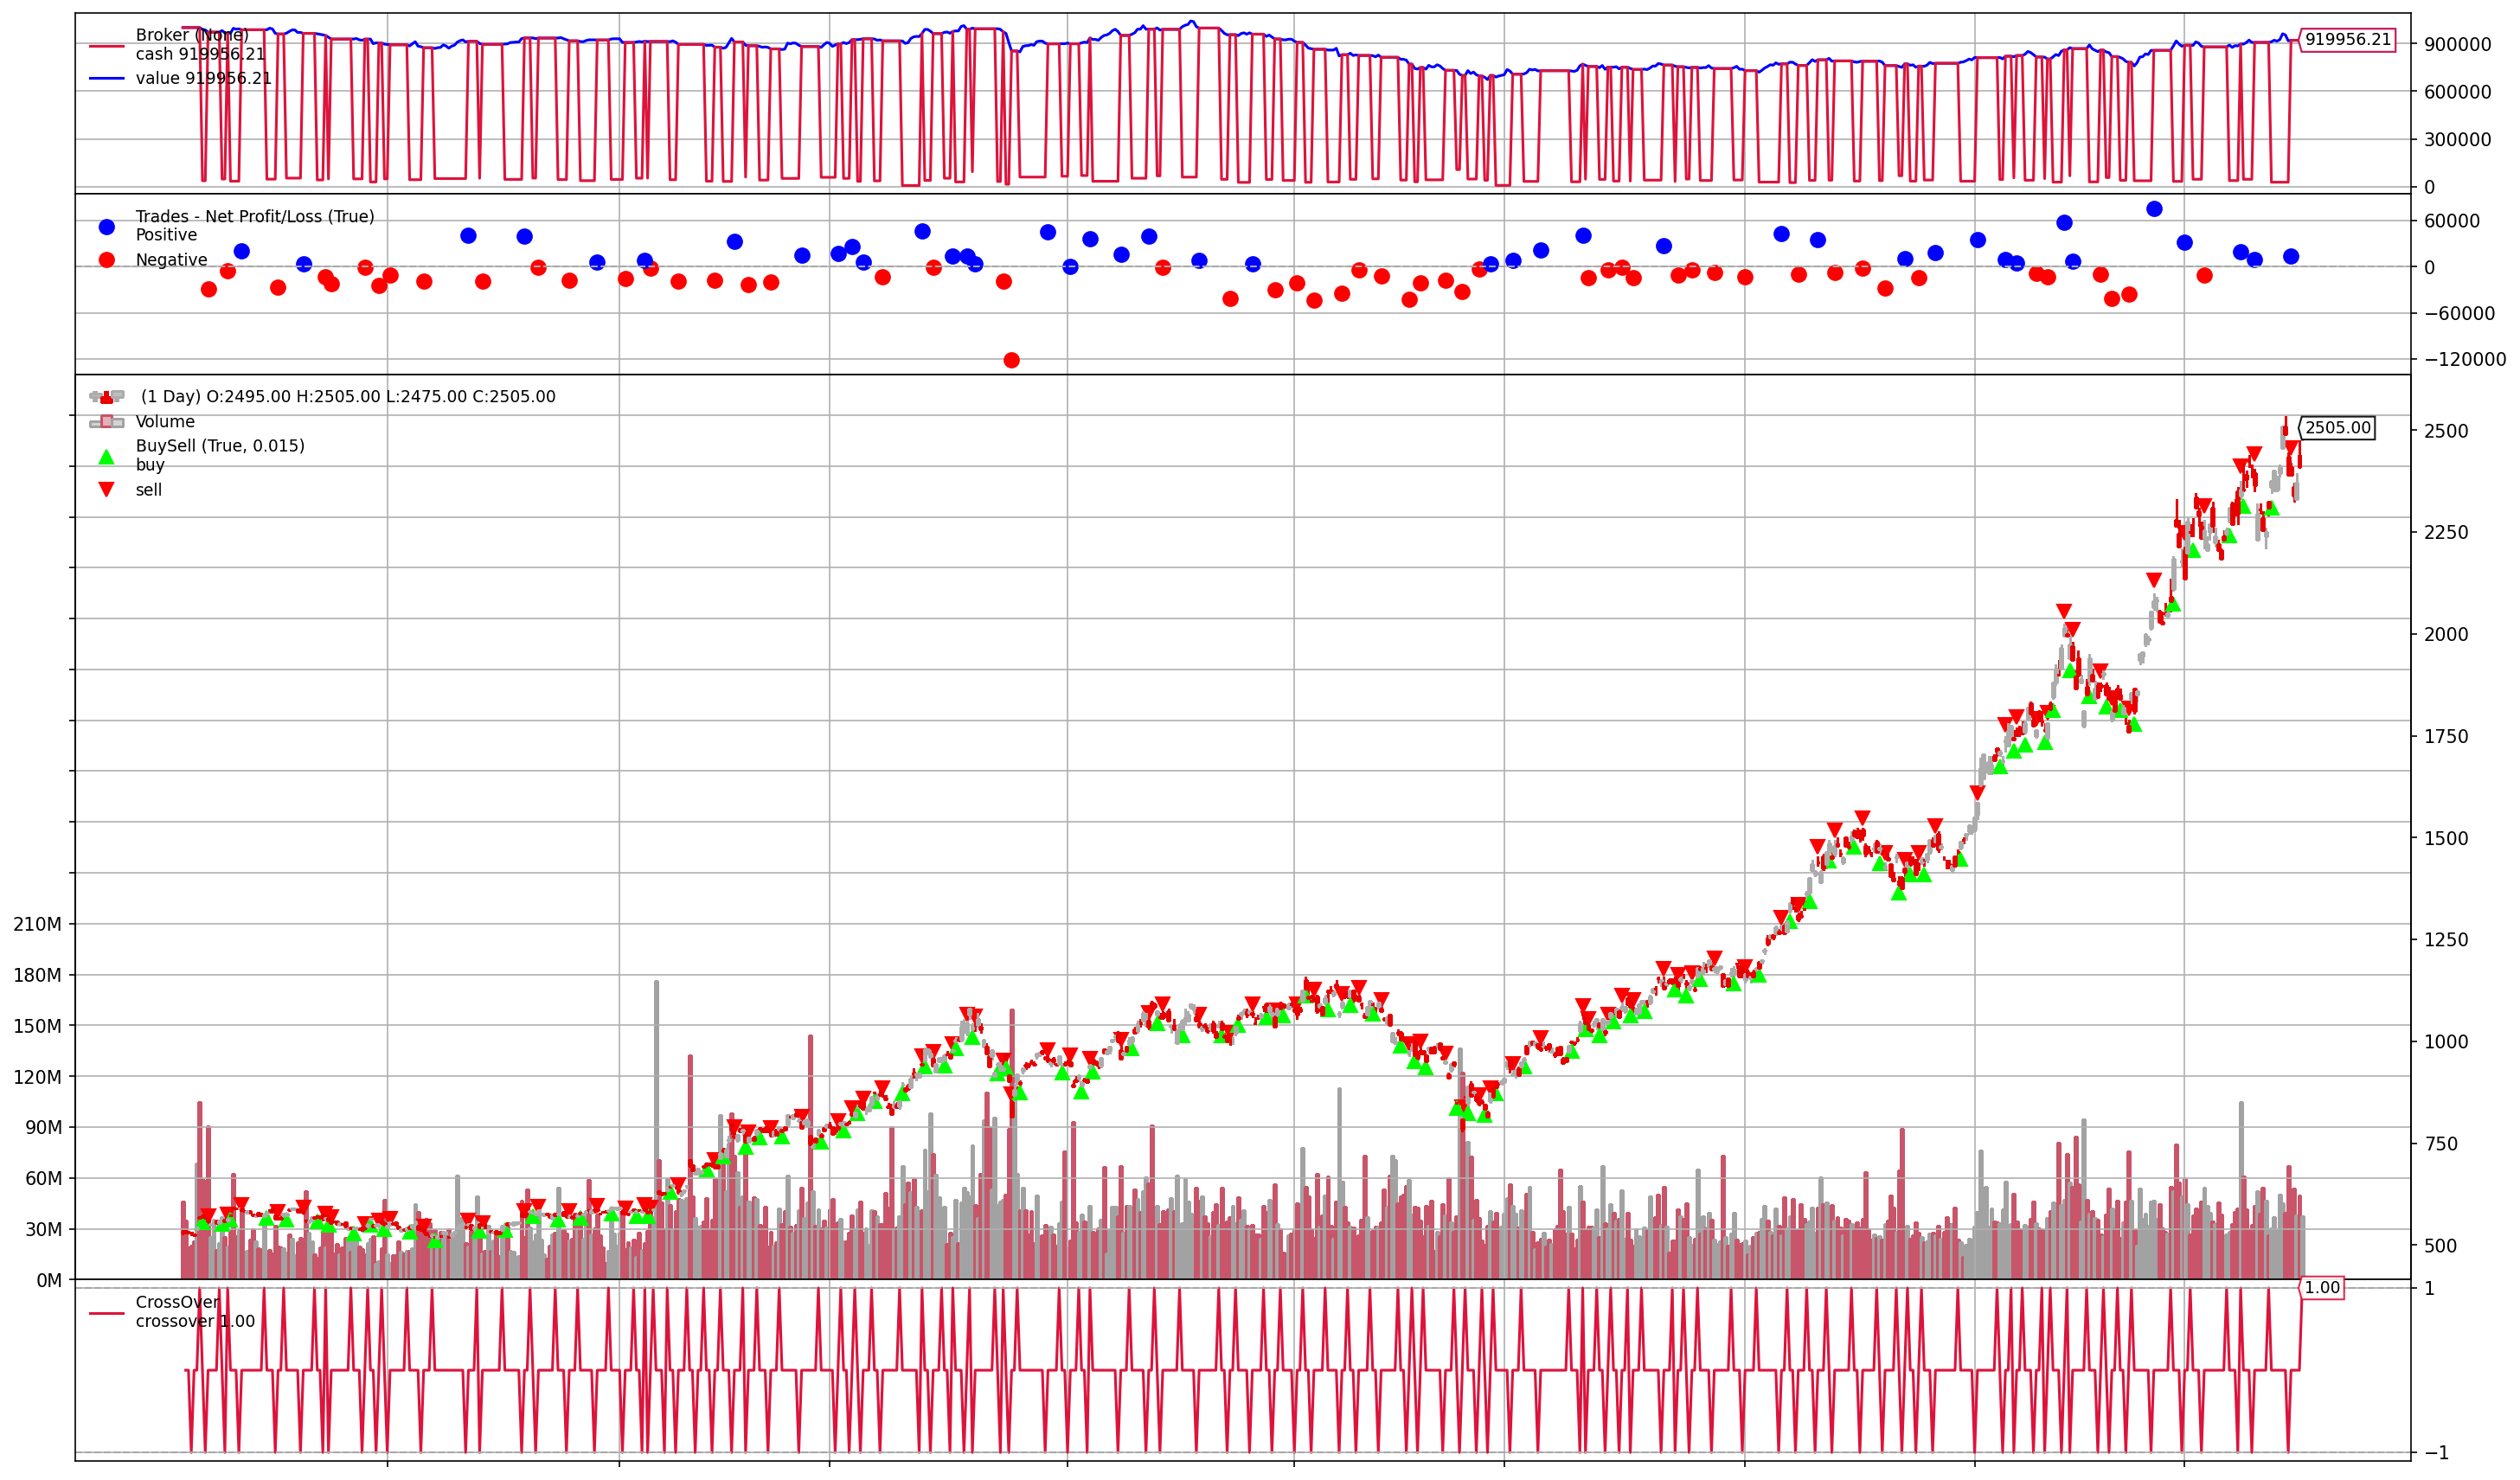

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 12]
plt.rcParams['figure.dpi'] = 150
figs = cerebro.plot(style="candlestick", iplot=False, heightp=0.5)

# KD超買超賣

In [ ]:
# 資料處理
df_bt = df.copy()
df_bt = df_bt[['date', 'open', 'max', 'min', 'close', 'K', 'D', 'Trading_Volume']]

df_bt = df_bt.rename(columns={
    "max": "high",
    "min": "low",
    "Trading_Volume": "volume"
})

df_bt = df_bt.dropna().reset_index(drop=True)
df_bt['date'] = pd.to_datetime(df_bt['date'])
df_bt = df_bt.set_index("date")

class PandasData(bt.feeds.PandasData):
    lines = ('k', 'd')
    params = (
        ('datetime', None),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
        ('k', 'K'),
        ('d', 'D'),
    )

# 手續費與證交稅
class TaiwanStockCommission(bt.CommissionInfo):
    params = (
        ("commission", 0.001425),
        ("tax", 0.003),
    )

    def _getcommission(self, size, price, pseudoexec):
        value = abs(size) * price
        commission = value * self.p.commission
        if size < 0:
            commission += value * self.p.tax
        return commission

# ALLIn Sizer
class AllInSizer(bt.Sizer):
    params = (("reserve", 0.05),)

    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            cash *= (1 - self.p.reserve)
            price = data.close[0]
            cost_per_share = price * (1 + comminfo.p.commission)
            size = int(cash / cost_per_share)
            return max(size, 0)
        return self.broker.getposition(data).size

# 修改後的 KD 策略 (新增 K, D 門檻 20 / 80 限制)
class KDStrategy(bt.Strategy):
    params = dict(
        stop_loss=0.10,     # 停損條件：10%
        kd_low=20,          # 低檔超賣區買入門檻
        kd_high=80          # 高檔超買區賣出門檻
    )

    def __init__(self):
        self.k = self.data.k
        self.d = self.data.d
        self.cross = bt.ind.CrossOver(self.k, self.d)
        self.order = None
        self.buyprice = None
        self.trades_history = []

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:
            date = self.data.datetime.date(0)
            exec_price = order.executed.price
            exec_size = abs(order.executed.size)
            exec_value = exec_price * exec_size

            comminfo = order.comminfo
            commission = exec_value * comminfo.p.commission
            tax = (exec_value * comminfo.p.tax) if order.issell() else 0.0

            current_value = self.broker.getvalue()
            pnl_pct = (current_value / 1_000_000 - 1) * 100

            if order.isbuy():
                self.buyprice = exec_price
                action = "買入"
            else:
                action = "賣出"

            self.trades_history.append({
                "交易日期": date,
                "買賣別": action,
                "成交價": round(exec_price, 2),
                "成交量(股)": exec_size,
                "交易金額": round(exec_value, 2),
                "手續費": round(commission, 2),
                "證交稅": round(tax, 2),
                "總資產": round(current_value, 2),
                "目前報酬率(%)": round(pnl_pct, 2)
            })

            print(f"{date} {action} | 價格:{exec_price:.2f} | 成交量:{exec_size} | 手續費:{commission:.0f} | 證交稅:{tax:.0f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print(f"{self.data.datetime.date(0)} 交易失敗 : {order.getstatusname()}")

        self.order = None

    def next(self):
        if self.order:
            return

        # 持有部位時的出場判斷
        if self.position:
            loss = (self.data.close[0] - self.buyprice) / self.buyprice

            # 停損機制
            if loss <= -self.p.stop_loss:
                print(f"{self.data.datetime.date(0)} 停損觸發")
                self.order = self.close()
                return

            # KD 死亡交叉 且 KD > 80 (高檔超買區賣出)
            # if self.cross < 0 and self.k[0] > self.p.kd_high and self.d[0] > self.p.kd_high:
            #     print(f"{self.data.datetime.date(0)} KD高檔死亡交叉(K:{self.k[0]:.1f}, D:{self.d[0]:.1f})")
            #     self.order = self.close()
            #     return

            # KD > 80 (高檔超買區賣出)
            if self.k[0] > self.p.kd_high and self.d[0] > self.p.kd_high:
                print(f"{self.data.datetime.date(0)} KD高檔(K:{self.k[0]:.1f}, D:{self.d[0]:.1f})")
                self.order = self.close()
                return

        # 空手時的進場判斷
        else:
            # KD 黃金交叉 且 KD < 20 (低檔超賣區買入)
            # if self.cross > 0 and self.k[0] < self.p.kd_low and self.d[0] < self.p.kd_low:
            #     print(f"{self.data.datetime.date(0)} KD低檔黃金交叉(K:{self.k[0]:.1f}, D:{self.d[0]:.1f})")
            #     self.order = self.buy()

            # KD < 20 (低檔超賣區買入)
            if self.k[0] < self.p.kd_low and self.d[0] < self.p.kd_low:
                print(f"{self.data.datetime.date(0)} KD低檔(K:{self.k[0]:.1f}, D:{self.d[0]:.1f})")
                self.order = self.buy()

    def stop(self):
        if self.position:
            print(f"回測結束，強制結算持股：{self.position.size}股")
            self.close()

# 執行回測與分析
cerebro = bt.Cerebro()
cerebro.addstrategy(KDStrategy)
cerebro.addsizer(AllInSizer, reserve=0.05)

data = PandasData(dataname=df_bt)
cerebro.adddata(data)
cerebro.broker.setcash(1_000_000)

comminfo = TaiwanStockCommission()
cerebro.broker.addcommissioninfo(comminfo)

cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.015, annualize=True, timeframe=bt.TimeFrame.Days)
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

print(f"初始資金：{cerebro.broker.getvalue():,.0f}")
results = cerebro.run()

# 轉為 DataFrame 與績效計算
strat = results[0]
df_trades = pd.DataFrame(strat.trades_history)

final_val = cerebro.broker.getvalue()
pnl_pct = (final_val / 1_000_000 - 1) * 100

if strat.position:
    last_date = strat.data.datetime.date(0)
    pos_size = strat.position.size
    close_price = strat.data.close[0]
    unrealized_value = pos_size * close_price

    unrealized_row = pd.DataFrame([{
        "交易日期": last_date,
        "買賣別": "結算",
        "成交價": round(close_price, 2),
        "成交量(股)": pos_size,
        "交易金額": round(unrealized_value, 2),
        "手續費": 0.0,
        "證交稅": 0.0,
        "總資產": round(final_val, 2),
        "目前報酬率(%)": round(pnl_pct, 2)
    }])

    df_trades = pd.concat([df_trades, unrealized_row], ignore_index=True)

df_trades.to_csv('df_trades.csv', index=False)

# 印出報告
print("\n" + "="*30)
print("策略整體績效評估")
print("="*30)

mdd = strat.analyzers.drawdown.get_analysis()['max']['drawdown']
sharpe_info = strat.analyzers.sharpe.get_analysis()
sharpe = sharpe_info.get('sharperatio', None)

trade_pnls = []
buy_record = None
for _, row in df_trades.iterrows():
    if row['買賣別'] == '買入':
        buy_record = row
    elif row['買賣別'] in ['賣出', '結算'] and buy_record is not None:
        cost = buy_record['交易金額'] + buy_record['手續費']
        revenue = row['交易金額'] - row['手續費'] - row['證交稅']
        pnl = revenue - cost
        trade_pnls.append(pnl)
        buy_record = None

trade_pnls = np.array(trade_pnls)

if len(trade_pnls) > 0:
    wins = trade_pnls[trade_pnls > 0]
    losses = trade_pnls[trade_pnls < 0]
    win_rate = (len(wins) / len(trade_pnls)) * 100
    avg_win = np.mean(wins) if len(wins) > 0 else 0
    avg_loss = abs(np.mean(losses)) if len(losses) > 0 else 0
    profit_factor = (avg_win / avg_loss) if avg_loss != 0 else np.nan
else:
    win_rate = 0.0
    profit_factor = 0.0

print(f"最終資金：{final_val:,.2f} 元")
print(f"總報酬率：{pnl_pct:.2f} %")
print(f"最大回撤 (MDD)：{mdd:.2f} %")
print(f"夏普比率(Sharpe)：{sharpe:.2f}" if sharpe is not None else "夏普比率 (Sharpe)：無法計算 (波動不足或無交易)")
print(f"總交易次數：{len(trade_pnls)} 次")
print(f"勝率：{win_rate:.2f} %")
print(f"賺賠比：{profit_factor:.2f}")
print("="*30)

print("\n=== 交易紀錄表 ===")
display(df_trades)
df_trades.to_csv('df_trades.csv', index=False)

初始資金：1,000,000
2023-08-08 KD低檔(K:13.0, D:18.2)
2023-08-09 買入 | 價格:550.00 | 成交量:1718 | 手續費:1346 | 證交稅:0
2023-10-12 KD高檔(K:96.3, D:80.2)
2023-10-13 賣出 | 價格:550.00 | 成交量:1718 | 手續費:1346 | 證交稅:2835
2023-10-27 KD低檔(K:13.5, D:18.8)
2023-10-30 買入 | 價格:531.00 | 成交量:1769 | 手續費:1339 | 證交稅:0
2023-11-08 KD高檔(K:90.8, D:87.6)
2023-11-09 賣出 | 價格:551.00 | 成交量:1769 | 手續費:1389 | 證交稅:2924
2024-07-23 KD低檔(K:9.9, D:12.0)
2024-07-26 買入 | 價格:915.00 | 成交量:992 | 手續費:1293 | 證交稅:0
2024-08-05 停損觸發
2024-08-06 賣出 | 價格:868.00 | 成交量:992 | 手續費:1227 | 證交稅:2583
2024-08-06 KD低檔(K:13.9, D:17.5)
2024-08-07 買入 | 價格:901.00 | 成交量:1048 | 手續費:1346 | 證交稅:0
2024-08-15 KD高檔(K:89.6, D:85.4)
2024-08-16 賣出 | 價格:963.00 | 成交量:1048 | 手續費:1438 | 證交稅:3028
2024-09-05 KD低檔(K:10.3, D:17.0)
2024-09-06 買入 | 價格:909.00 | 成交量:1084 | 手續費:1404 | 證交稅:0
2024-09-19 KD高檔(K:88.7, D:86.0)
2024-09-20 賣出 | 價格:981.00 | 成交量:1084 | 手續費:1515 | 證交稅:3190
2024-11-19 KD低檔(K:17.0, D:17.9)
2024-11-20 買入 | 價格:1045.00 | 成交量:1006 | 手續費:1498 | 證交稅:0
2024-12-06 KD高檔(K:92

,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2023-08-09,買入,550.0,1718,944900.0,1346.48,0.00,1005525.52,0.55
1,2023-10-13,賣出,550.0,1718,944900.0,1346.48,2834.70,994472.33,-0.55
2,2023-10-30,買入,531.0,1769,939339.0,1338.56,0.00,994902.78,-0.51
3,2023-11-09,賣出,551.0,1769,974719.0,1388.97,2924.16,1024200.65,2.42
4,2024-07-26,買入,915.0,992,907680.0,1293.44,0.00,1031835.20,3.18
5,2024-08-06,賣出,868.0,992,861056.0,1227.00,2583.17,972473.03,-2.75
6,2024-08-07,買入,901.0,1048,944248.0,1345.55,0.00,991039.48,-0.90
7,2024-08-16,賣出,963.0,1048,1009224.0,1438.14,3027.67,1031637.66,3.16
8,2024-09-06,買入,909.0,1084,985356.0,1404.13,0.00,1039989.53,4.00
9,2024-09-20,賣出,981.0,1084,1063404.0,1515.35,3190.21,1103575.96,10.36


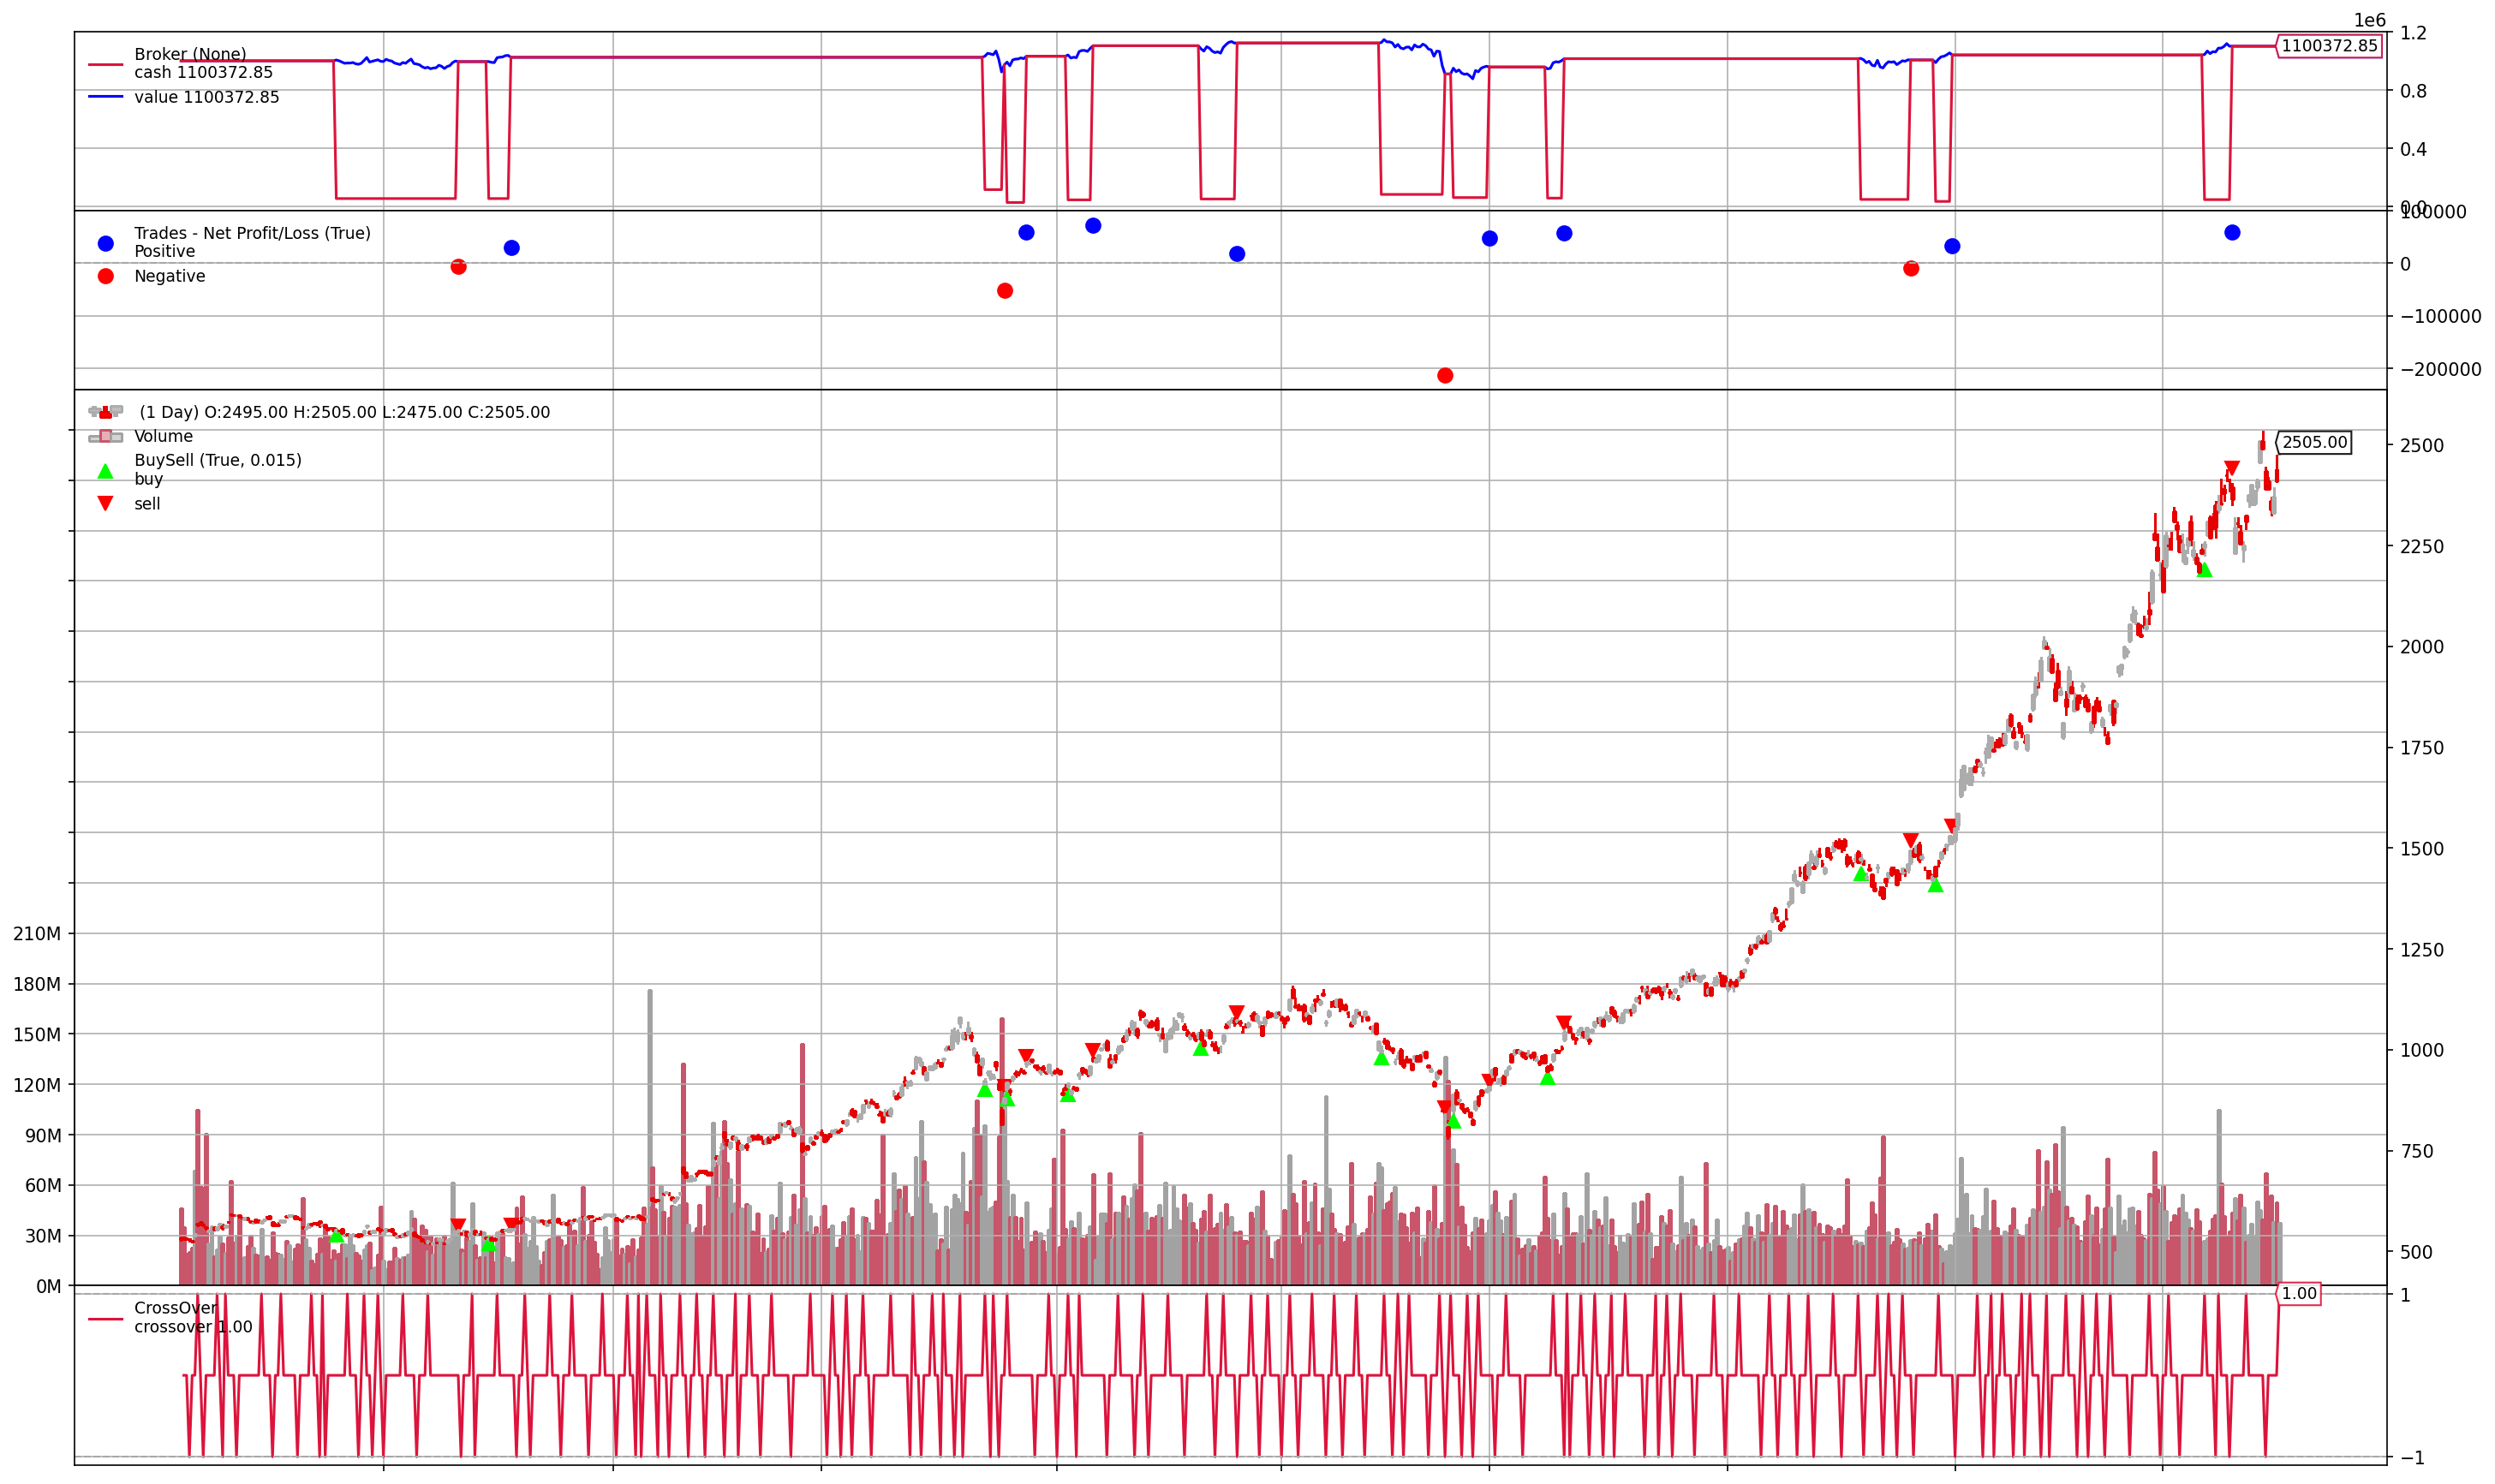

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 12]
plt.rcParams['figure.dpi'] = 150
figs = cerebro.plot(style="candlestick", iplot=False, heightp=0.5)

# 參考資料

https://ithelp.ithome.com.tw/m/articles/10242427

https://vocus.cc/article/67f8ebfbfd8978000177661f

https://finlab.finance/blog/what-is-backtesting